# Mass-Radius Relation (From Saved TOV Data)

This notebook loads precomputed TOV solutions saved by `solver-tov.py` and plots the mass-radius relation.
It does not recompute the TOV integration.

In [6]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
M_sun_cgs = 1.989e33   # g
cm2km = 1e5

def mass_g2Msun(m_km):
    m_cgs = m_km * cm2km
    m_msun = m_cgs / G_cgs * (c_cgs**2) / M_sun_cgs
    return m_msun


In [7]:
# Parameters matching the saved data naming
h = "1e-4"
eps = "1e-3"

base_dir = "/Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid"
target_dir = os.path.join(base_dir, f"h{h}_eps{eps}")

pm_path = os.path.join(target_dir, "PMSol.pkl")
r_path = os.path.join(target_dir, "RArr.pkl")

print("Loading:")
print("  ", pm_path)
print("  ", r_path)


Loading:
   /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/PMSol.pkl
   /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/RArr.pkl


In [8]:
with open(pm_path, "rb") as f:
    SolArr = pickle.load(f)

with open(r_path, "rb") as f:
    RArr = pickle.load(f)

print(f"Loaded {len(SolArr)} models")


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_12657/3911113574.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  SolArr = pickle.load(f)


Loaded 25 models


In [9]:
# Extract mass-radius points: use the second-to-last entry (surface crossing)
M_list = []
R_list = []

for sol, rgrid in zip(SolArr, RArr):
    m_last = sol[-2][0]
    r_last = rgrid[-2]
    M_list.append(mass_g2Msun(m_last))
    R_list.append(r_last)

M = np.array(M_list)
R = np.array(R_list)

print("Mass range (Msun):", M.min(), M.max())
print("Radius range (geom units):", R.min(), R.max())


Mass range (Msun): 0.539467045613192 1.715577357892533
Radius range (geom units): 9.063199999992216 18.178899999970973


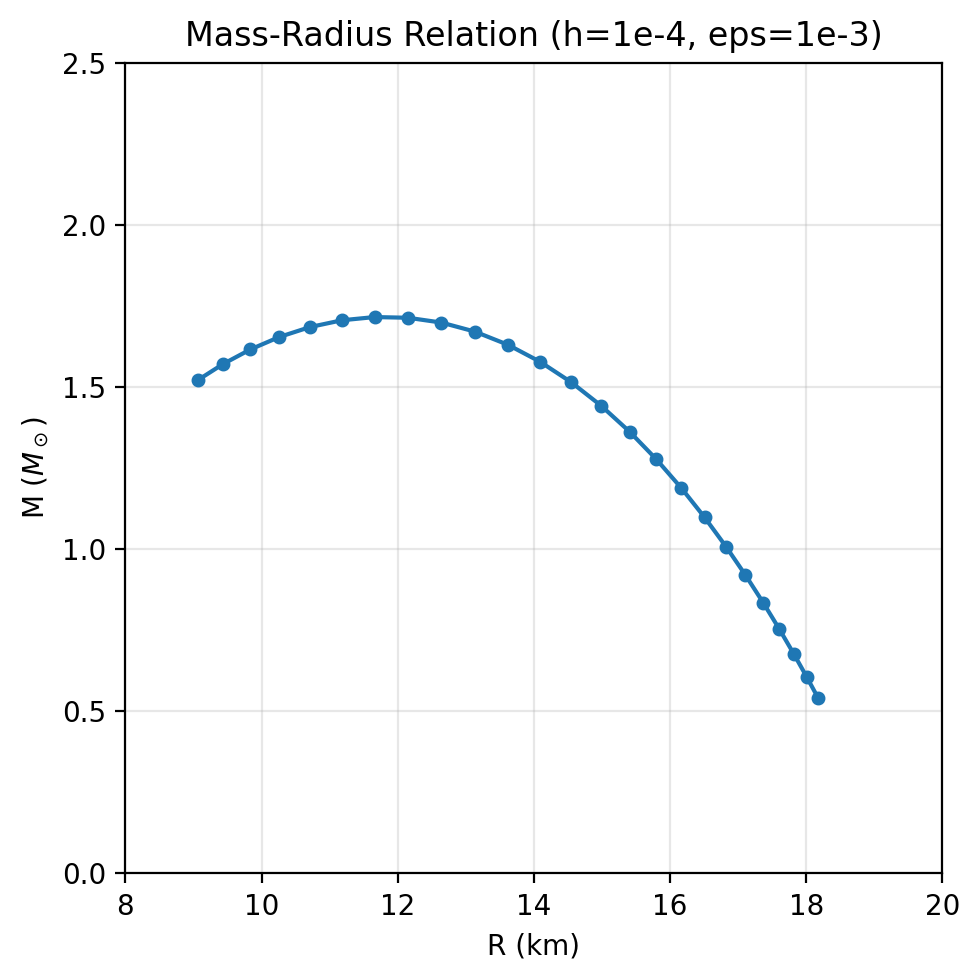

In [10]:
plt.figure(figsize=(5, 5), dpi=200)
plt.plot(R, M, "o-", lw=1.5, ms=4)
plt.xlabel("R (km)")
plt.ylabel(r"M ($M_\odot$)")
plt.title(f"Mass-Radius Relation (h={h}, eps={eps})")
plt.grid(True, alpha=0.3)
plt.xlim(8,20)
plt.ylim(0,2.5)
plt.tight_layout()
plt.show()
